In [ ]:
pip install evaluate
pip install seqeval
pip install datasets==2.16.1 fsspec==2023.6.0

## Установка библиотек

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, classification_report

from datasets import load_dataset
from collections import Counter
import evaluate
import numpy as np
import seaborn as sns
import pandas as pd
import random
from collections import defaultdict
import matplotlib.pyplot as plt

from transformers import BertConfig, BertModel, BertTokenizerFast, BertForSequenceClassification, TrainingArguments, Trainer, get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup

In [ ]:
def set_random_seed(seed):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_random_seed(224)

In [ ]:
ds = load_dataset("ai-forever/kinopoisk-sentiment-classification")

In [ ]:
tokenizer = BertTokenizerFast.from_pretrained('DeepPavlov/rubert-base-cased')

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

In [ ]:
def parse_dataset(filepath):
    texts, slots, classes = [], [], []
    with open(filepath, 'r', encoding='utf-8') as file:
        current_text, current_slots, current_classes = [], [], []
        text_id = 0
        for line in file:
            line = line.strip()
            if line.startswith('# sent_id'):
              c = line.split()[3]
              sent, text = c.split('_')
              if text_id != int(text):
                texts.append(current_text)
                slots.append(current_slots)
                classes.append(current_classes)
                text_id = int(text)
                current_text, current_slots, current_classes = [], [], []
            elif line.startswith('# text'):
              continue
            elif not line:
              continue
            else:
                l = line.split('\t')
                current_text.append(l[1])
                current_classes.append(l[-1])
                current_slots.append(l[-2])
        if current_text:
          texts.append(current_text)
          slots.append(current_slots)
          classes.append(current_classes)
    return texts, slots, classes

In [ ]:
from collections import defaultdict

def extract_classes_and_slots(filepath1, filepath2):
    classes = set()
    slots = set()

    with open(filepath1, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            fields = line.split('\t')
            if len(fields) < 11:
                continue
            class_field = fields[11]
            slot_field = fields[10]
            classes.add(class_field)
            slots.add(slot_field)

    with open(filepath2, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            fields = line.split('\t')
            if len(fields) < 11:
                continue
            class_field = fields[11]
            slot_field = fields[10]
            classes.add(class_field)
            slots.add(slot_field)


    classes = sorted(classes)
    slots = sorted(slots)
    classes.append('PAD')
    slots.append('PAD')

    class2idx = {cls: idx for idx, cls in enumerate(classes)}
    idx2class = {idx: cls for cls, idx in class2idx.items()}

    slot2idx = {slot: idx for idx, slot in enumerate(slots)}
    idx2slot = {idx: slot for slot, idx in slot2idx.items()}

    return {
        'classes': classes,
        'slots': slots,
        'class2idx': class2idx,
        'idx2class': idx2class,
        'slot2idx': slot2idx,
        'idx2slot': idx2slot
    }

In [ ]:
class SemDataset(Dataset):
    def __init__(self, texts, slots, classes, labels, tokenizer, slot2id, class2id, max_length=256):
        self.texts = texts
        self.slots = slots
        self.classes = classes
        self.labels = labels # просто тензор
        self.tokenizer = tokenizer
        self.slot2id = slot2id
        self.class2id = class2id
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def align_tokens_and_labels(self, tokens, slots, classes):
        # тут нам надо сделать так, чтобы слоты и классы были правильно приписаны сабтокенам, на которые поделил токенайзер
        # будем приписывать всем сабтокенам, которые относятся к одному слову в конллу одинаковые слоты и классы
        word_ids = self.tokenizer.convert_tokens_to_ids(tokens)  # Индексы токенов
        aligned_slots = []
        aligned_classes = []

        current_word_idx = 0
        for word in word_ids:
            # Получаем текущий токен из разметки
            current_word = tokens[current_word_idx]

            # Получаем количество токенов для текущего слова из разметки
            original_word_token_count = len(self.tokenizer.tokenize(current_word))

            # Присваиваем всем токенам этого слова одинаковый тег
            for _ in range(original_word_token_count):
                aligned_slots.append(slots[current_word_idx])
                aligned_classes.append(classes[current_word_idx])

            # Переходим к следующему слову в разметке
            current_word_idx += 1

        return aligned_slots, aligned_classes

    def slice_token(self, index):
        start, stop, step = index.indices(len(self.texts))
        result = []
        for i in range(start, stop, step):
            tokens = self.texts[i]
            classes = self.classes[i]
            slots = self.slots[i]
            label = self.labels[i]
            encoding = self.tokenizer(
                            tokens,
                            is_split_into_words=True,
                            padding='max_length',
                            truncation=True,
                            max_length=self.max_length,
                            return_tensors='pt'
                        )

            slots, classes = self.align_tokens_and_labels(tokens, slots, classes)

            pad_len = self.max_length - len(slots)
            if pad_len > 0:
                for i in range(pad_len):
                    slots.append('PAD')
                    classes.append('PAD')
            else:
                slots = slots[:self.max_length]
                classes = classes[:self.max_length]

            slots = [self.slot2id[slot] for slot in slots]
            classes = [self.class2id[cls] for cls in classes]

            encoding["slots"] = slots
            encoding["classes"] = classes
            encoding["label"] = label
            encoding["input_ids"] = torch.squeeze(encoding["input_ids"], 0)
            encoding["token_type_ids"] = torch.squeeze(encoding["token_type_ids"], 0)
            encoding["attention_mask"] = torch.squeeze(encoding["attention_mask"], 0)

            assert torch.max(encoding["input_ids"]) < tokenizer.vocab_size, f"Bad input_ids: {encoding['input_ids']}"
            assert torch.max(encoding["token_type_ids"]) <= 1, f"token_type_ids invalid: {encoding['token_type_ids']}"
            assert all(0 <= x < len(self.slot2id) or x == -100 for x in slots), f"slots out of range: {slots}"
            assert all(0 <= x < len(self.class2id) or x == -100 for x in classes), f"classes out of range: {classes}"
            assert isinstance(label, int) and 0 <= label < 3, f"label out of range: {label}"
            result.append({key: torch.tensor(val) for key, val in encoding.items()})

        return result

    def __getitem__(self, idx):
        if isinstance(idx, slice):
            # Обработка среза
            return self.slice_token(idx)
        elif isinstance(idx, int):
            tokens = self.texts[idx]
            classes = self.classes[idx]
            slots = self.slots[idx]
            label = self.labels[idx]

            encoding = self.tokenizer(
                        tokens,
                        is_split_into_words=True,
                        padding='max_length',
                        truncation=True,
                        max_length=self.max_length,
                        return_tensors='pt'
                    )

            slots, classes = self.align_tokens_and_labels(tokens, slots, classes)

            # добавляем паддинг в слоты и классы
            pad_len = self.max_length - len(slots)
            if pad_len > 0:
                for i in range(pad_len):
                    slots.append('PAD')
                    classes.append('PAD')
            else:
                slots = slots[:self.max_length]
                classes = classes[:self.max_length]

            slots = [self.slot2id[slot] for slot in slots]
            classes = [self.class2id[cls] for cls in classes]

            encoding["slots"] = slots
            encoding["classes"] = classes
            encoding["label"] = label
            encoding["input_ids"] = torch.squeeze(encoding["input_ids"], 0)
            encoding["token_type_ids"] = torch.squeeze(encoding["token_type_ids"], 0)
            encoding["attention_mask"] = torch.squeeze(encoding["attention_mask"], 0)
            #encoding.pop("offset_mcodinfapping")  # для модели не нужно
            #print(encoding)

            assert torch.max(encoding["input_ids"]) < tokenizer.vocab_size, f"Bad input_ids: {encoding['input_ids']}"
            assert torch.max(encoding["token_type_ids"]) <= 1, f"token_type_ids invalid: {encoding['token_type_ids']}"
            assert all(0 <= x < len(self.slot2id) or x == -100 for x in slots), f"slots out of range: {slots}"
            assert all(0 <= x < len(self.class2id) or x == -100 for x in classes), f"classes out of range: {classes}"
            assert isinstance(label, int) and 0 <= label < 3, f"label out of range: {label}"

            return {key: torch.tensor(val) for key, val in encoding.items()}

In [ ]:
def create_dataloader_train(path, labels, tokenizer, slots2id, classes2id, batch_size=16, max_length=256):
    texts, slots, classes = parse_dataset(path)
    dataset = SemDataset(texts, slots, classes, labels, tokenizer, slots2id, classes2id, max_length=max_length)
    little_dataset = dataset[0:1000]
    return DataLoader(little_dataset, batch_size=batch_size, shuffle=False) #shuffle=True

def create_dataloader_val(path, labels, tokenizer, slots2id, classes2id, batch_size=16, max_length=256):
    texts, slots, classes = parse_dataset(path)
    dataset = SemDataset(texts, slots, classes, labels, tokenizer, slots2id, classes2id, max_length=max_length)
    little_dataset_val = dataset[0:300]
    little_dataset_test = dataset[300:600]
    return DataLoader(little_dataset_val, batch_size=batch_size, shuffle = False), DataLoader(little_dataset_test, batch_size=batch_size, shuffle = False)

In [ ]:
#model_checkpoint = "DeepPavlov/rubert-base-cased"
#tokenizer = BertTokenizerFast.from_pretrained(model_checkpoint)

# достаем все слоты и классы, делаем словари с их id
extracted = extract_classes_and_slots('/content/drive/MyDrive/Colab Notebooks/курсач/датасеты/сентимент/sentiment_train_pred.conllu', '/content/drive/MyDrive/Colab Notebooks/курсач/датасеты/сентимент/sentiment_val_pred.conllu')
train_dataloader = create_dataloader_train('/content/drive/MyDrive/Colab Notebooks/курсач/датасеты/сентимент/sentiment_train_pred.conllu', ds['train']['label'], tokenizer, extracted['slot2idx'], extracted['class2idx'], batch_size=16)
val_dataloader, test_dataloader = create_dataloader_val('/content/drive/MyDrive/Colab Notebooks/курсач/датасеты/сентимент/sentiment_val_pred.conllu', ds['validation']['label'], tokenizer, extracted['slot2idx'], extracted['class2idx'], batch_size=16)

<ipython-input-11-3250076881>:83: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  result.append({key: torch.tensor(val) for key, val in encoding.items()})


In [ ]:
class BiLSTMPooling(nn.Module):
    def __init__(self, emb_dim, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_size,
            bidirectional=True,
            batch_first=True
        )

    def forward(self, token_embeddings):
        # token_embeddings: [batch_size, seq_len, emb_dim]
        lstm_out, _ = self.lstm(token_embeddings)  # [batch_size, seq_len, 2*hidden_size]
        return lstm_out.mean(dim=1)  # Mean pooling over sequence

In [ ]:
class SentimentClassifier(nn.Module):
  def __init__(self, num_labels, num_semantic_classes, num_semantic_slots, semantic_emb_dim=128, lstm_hidden_size=64):
  #def __init__(self, n_classes):
    super().__init__()
    self.bert = BertModel.from_pretrained("DeepPavlov/rubert-base-cased")
    self.drop = nn.Dropout(p=0.3)
    #self.out = nn.Linear(self.bert.config.hidden_size, n_classes)
    #self.loss_fct = nn.CrossEntropyLoss()

    self.semantic_class_embedding = nn.Embedding(num_semantic_classes, semantic_emb_dim)
    self.semantic_slot_embedding = nn.Embedding(num_semantic_slots, semantic_emb_dim)

    # BiLSTM для обработки семантических последовательностей
    self.semantic_lstm = BiLSTMPooling(emb_dim=semantic_emb_dim, hidden_size=lstm_hidden_size)

    # Классификатор — BERT + BiLSTM(class) + BiLSTM(slot)
    self.classifier = nn.Linear(self.bert.config.hidden_size + 2 * 2 * lstm_hidden_size, num_labels)

    #self.classifier = nn.Linear(self.bert.config.hidden_size + 2 * semantic_emb_dim, num_labels)

  def forward(self, input_ids=None, token_type_ids=None, attention_mask=None, slots=None, classes=None):
  #def forward(self, input_ids, attention_mask):
    _, pooled_output = self.bert(
      input_ids=input_ids,
      attention_mask=attention_mask,
      return_dict=False)

    mask = attention_mask.unsqueeze(-1).float()

    # Эмбеддинги семантики: предполагается, что slots и classes — (batch_size,)
    semantic_class_embeds = self.semantic_class_embedding(classes)  # (batch_size, sem_emb_dim)
    semantic_slot_embeds = self.semantic_slot_embedding(slots)      # (batch_size, sem_emb_dim)

    semantic_class_embeds = semantic_class_embeds * mask
    semantic_slot_embeds = semantic_slot_embeds * mask
    """
    # Сумма по токенам
    class_embeds_sum = semantic_class_embeds.sum(dim=1)  # (batch_size, sem_emb_dim)
    slot_embeds_sum =  semantic_slot_embeds.sum(dim=1)

    # Количество непаддинговых токенов
    lengths = mask.sum(dim=1).clamp(min=1e-6)  # (batch_size, 1)

    # Среднее
    class_embeds_avg = class_embeds_sum / lengths
    slot_embeds_avg = slot_embeds_sum / lengths

    # Dropout
    combined_output = torch.cat([pooled_output, class_embeds_avg, slot_embeds_avg], dim=-1)
    """

    class_summary = self.semantic_lstm(semantic_class_embeds)  # (batch_size, 2 * hidden_size)
    slot_summary = self.semantic_lstm(semantic_slot_embeds)    # (batch_size, 2 * hidden_size)

        # Объединяем
    combined = torch.cat([pooled_output, class_summary, slot_summary], dim=1)  # (batch_size, ...)

    #output = self.drop(pooled_output)

    return self.classifier(combined)

In [ ]:
num_labels = len(set(ds['train']['label']))
num_semantic_classes = len(extracted['classes'])
num_semantic_slots = len(extracted['slots'])

model = SentimentClassifier(num_labels=num_labels,
    num_semantic_classes=num_semantic_classes,
    num_semantic_slots=num_semantic_slots)

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
EPOCHS = 3

#optimizer = AdamW(model.parameters(), lr=2e-5, correct_bias=False)
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5) #correct_bias=False
total_steps = len(train_dataloader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
  optimizer,
  num_warmup_steps=0,
  num_training_steps=total_steps
)

loss_fn = nn.CrossEntropyLoss().to(device)

In [ ]:
def train_epoch(
  model,
  data_loader,
  loss_fn,
  optimizer,
  device,
  scheduler,
  n_examples
):
  model = model.train()

  losses = []
  all_preds = []
  all_labels = []

  for d in data_loader:
    input_ids = d["input_ids"].to(device)
    attention_mask = d["attention_mask"].to(device)
    targets = d["label"].to(device)
    slots = d['slots'].to(device)
    classes = d['classes'].to(device)

    outputs = model(
      input_ids=input_ids,
      attention_mask=attention_mask,
      slots=slots,
      classes=classes)

    loss = loss_fn(outputs, targets)

    all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
    all_labels.extend(targets.cpu().numpy())

    losses.append(loss.item())

    loss.backward()
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

  precision, recall, f1, _ = precision_recall_fscore_support(
  all_labels, all_preds, average='binary', zero_division=0)
  acc = accuracy_score(all_labels, all_preds)
  print(confusion_matrix(all_labels, all_preds))

  return precision, recall, f1, acc, np.mean(losses)

In [ ]:
def eval_model(model, data_loader, loss_fn, device, n_examples):
  model = model.eval()

  losses = []
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["label"].to(device)
      slots = d['slots'].to(device)
      classes = d['classes'].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        slots=slots,
        classes=classes
      )

      loss = loss_fn(outputs, targets)

      all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
      all_labels.extend(targets.cpu().numpy())

      losses.append(loss.item())

  precision, recall, f1, _ = precision_recall_fscore_support(
  all_labels, all_preds, average='binary', zero_division=0)
  acc = accuracy_score(all_labels, all_preds)
  print(confusion_matrix(all_labels, all_preds))

  return precision, recall, f1, acc, np.mean(losses)

In [ ]:
%%time

history = defaultdict(list)
#best_accuracy = 0

for epoch in range(EPOCHS):

  print(f'Epoch {epoch + 1}/{EPOCHS}')
  print('-' * 10)

  train_precision, train_recall, train_f1, train_acc, train_loss = train_epoch(
    model,
    train_dataloader,
    loss_fn,
    optimizer,
    device,
    scheduler,
    1000
  )

  print(f'Train loss {train_loss} train_acc {train_acc} train_precision {train_precision}, train_recall {train_recall}, train_f1 {train_f1}')

  val_precision, val_recall, val_f1, val_acc, val_loss = eval_model(
    model,
  val_dataloader,
    loss_fn,
    device,
    300
  )

  print(f'Val loss {val_loss} val_acc {val_acc} val_precision {val_precision}, val_recall {val_recall}, val_f1 {val_f1}')
  print()

  history['train_acc'].append(train_acc)
  history['train_loss'].append(train_loss)
  history['val_acc'].append(val_acc)
  history['val_loss'].append(val_loss)
  """
  if val_acc > best_accuracy:
    torch.save(model.state_dict(), 'best_model_state.bin')
    best_accuracy = val_acc
  """

Epoch 1/2
----------
Train loss 1.1000329729110476 accuracy 0.3500000238418579
Val loss 1.093224236839696 accuracy 0.36000001430511475

Epoch 2/2
----------
Train loss 1.0138091340897575 accuracy 0.4650000333786011
Val loss 0.8904498564569574 accuracy 0.596666693687439

CPU times: user 1min 23s, sys: 2.47 s, total: 1min 26s
Wall time: 1min 44s


In [ ]:
history['train_acc'] = [score.to('cpu') for score in  history['train_acc']]
history['val_acc'] = [score.to('cpu') for score in  history['val_acc']]

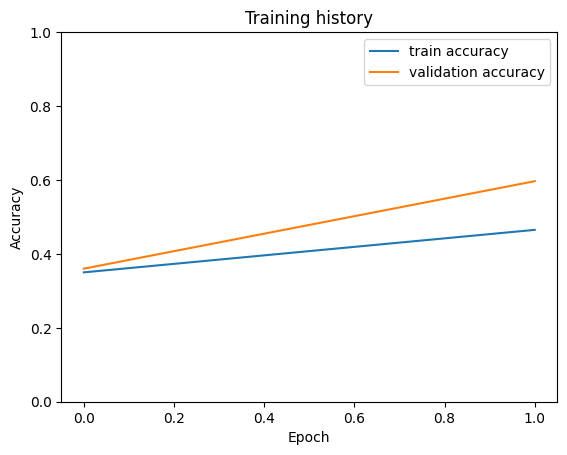

In [ ]:
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')

plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);

In [ ]:
test_acc, _ = eval_model(
  model,
  val_dataloader,
  loss_fn,
  device,
  1000
)

test_acc.item()

0.17900000512599945

In [ ]:
def get_predictions(model, data_loader):
  model = model.eval()

  #review_texts = []
  predictions = []
  prediction_probs = []
  real_values = []

  with torch.no_grad():
    for d in data_loader:

      #texts = d["review_text"]
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["label"].to(device)
      slots = d['slots'].to(device)
      classes = d['classes'].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        slots=slots,
        classes=classes
      )
      preds = torch.argmax(outputs, dim=1)

      probs = F.softmax(outputs, dim=1)

      #review_texts.extend(texts)
      predictions.extend(preds)
      prediction_probs.extend(probs)
      real_values.extend(targets)

  predictions = torch.stack(predictions).cpu()
  prediction_probs = torch.stack(prediction_probs).cpu()
  real_values = torch.stack(real_values).cpu()
  return predictions, prediction_probs, real_values

In [ ]:
y_pred, y_pred_probs, y_test = get_predictions(model, val_dataloader)

In [ ]:
print(classification_report(y_test, y_pred, target_names=['0', '1', '2']))

              precision    recall  f1-score   support

           0       0.61      0.79      0.69       107
           1       0.44      0.28      0.34        96
           2       0.67      0.70      0.69        97

    accuracy                           0.60       300
   macro avg       0.57      0.59      0.57       300
weighted avg       0.58      0.60      0.58       300



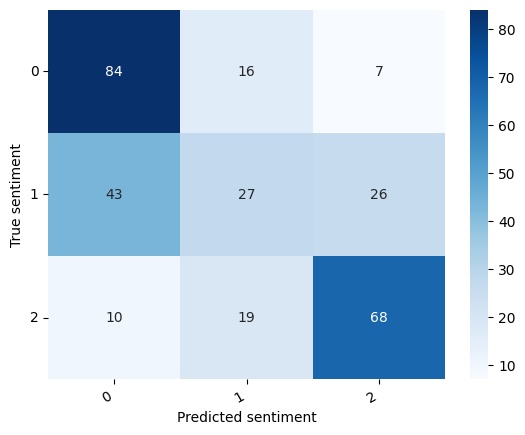

In [ ]:
def show_confusion_matrix(confusion_matrix):
  hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('True sentiment')
  plt.xlabel('Predicted sentiment');

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=['0', '1', '2'], columns=['0', '1', '2'])
show_confusion_matrix(df_cm)



---

старое

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',          # Output directory
    eval_strategy="epoch",    # Evaluate after each epoch
    learning_rate=1.8562022777790423e-05,             # Learning rate
    per_device_train_batch_size=32, # Batch size for training
    per_device_eval_batch_size=32,  # Batch size for evaluation
    num_train_epochs=3,             # Number of epochs
    weight_decay=0.001928128030703447,              # Strength of weight decay
    logging_dir="./logs",           # Directory for storing logs
    logging_steps=10,               # что это такое?
    save_strategy="epoch",          # Save model after each epoch
    load_best_model_at_end=True,    # Load the best model after training
    metric_for_best_model="f1", # Use F1 score to choose the best model
    seed=224
)

In [ ]:
def compute_metrics(p):

    predictions, labels = p
    # логиты в индексы
    predictions = predictions.argmax(axis=-1)
    cm = confusion_matrix(labels, predictions)

    print("Confusion Matrix:\n", cm)
    # пихнем в метрику и получим результат
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro')
    acc = accuracy_score(labels, predictions)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [ ]:
def hp_space_fn(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1e-3,log=True),
        "weight_decay" : trial.suggest_float("weight_decay", 1e-5, 0.1, log=True) # логарифмический масштаб для lr
        }

def model_init():
    return BertForSequenceClassification.from_pretrained('google-bert/bert-base-uncased', num_labels = len(set(ds['train']['label'])))

In [ ]:
trainer = Trainer(
    model=model,
    #model_init = model_init,
    args=training_args,
    train_dataset=little_train_loader.dataset,  # Training dataset
    eval_dataset=little_val_loader.dataset,   # Evaluation dataset
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    #optimizers=(optimizer, scheduler)
    )


NameError: name 'little_train_loader' is not defined

In [ ]:
!pip install optuna

In [ ]:
best_run = trainer.hyperparameter_search(
    hp_space=hp_space_fn,
    n_trials=5, # количество запусков с разными гиперпараметрами
    direction="maximize", # максимизируем f1
    backend="optuna" # backend для поиска по сетке
)

In [ ]:
best_run.hyperparameters
#{'learning_rate': 1.8562022777790423e-05, 'weight_decay': 0.001928128030703447}

In [ ]:
!wandb login --relogin

In [ ]:
# собственно обучение - автоматически делает логи
trainer.train()

# оценим модельку
eval_results = trainer.evaluate()
print(f"Evaluation Results: {eval_results}")

# Сохраним, что получилось
trainer.save_model("./ner_model")
#b5a31e3a762dc4fdbd905c7a205899ee8116917a

In [ ]:
def eval_model(model, data_loader, device):
  model = model.eval()

  all_preds = torch.tensor([], device=device)
  all_trues = torch.tensor([], device=device)

  with torch.no_grad():
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["labels"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      #print(outputs)
      preds = torch.argmax(outputs['logits'], axis=-1)
      all_preds = torch.cat((all_preds, preds), -1)
      all_trues = torch.cat((all_trues, targets), -1)

  precision, recall, f1, _ = precision_recall_fscore_support(all_trues.cpu(), all_preds.cpu(), average='macro')
  acc = accuracy_score(all_trues.cpu(), all_preds.cpu())
  return {
      'accuracy': acc,
      'f1': f1,
      'precision': precision,
      'recall': recall
  }

In [ ]:
test = eval_model(model, test_loader, device)

In [ ]:
test

In [ ]:
precision, recall, f1, _ = precision_recall_fscore_support(torch.tensor(ds['test']['label']), torch.zeros(1500), average='macro')
acc = accuracy_score(torch.tensor(ds['test']['label']), torch.zeros(1500))
print({
      'accuracy': acc,
      'f1': f1,
      'precision': precision,
      'recall': recall})

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True) # Подключите Google Drive
!cp -r /content/results /content/drive/MyDrive/чекпоинты # Замените на ваши пути